<a href="https://colab.research.google.com/github/ramyamurugesh-eng/Engineering-Multimodal-AI/blob/main/Audio_Preprocessing__Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎵 Audio Preprocessing Pipeline for AI & Machine Learning

## Objective

In many Artificial Intelligence (AI) and Machine Learning (ML) applications, audio recordings cannot be used directly for model training. Real-world audio often contains background noise, varying loudness, silence, and other unwanted components that can reduce the performance of machine learning models.

Audio preprocessing is the process of cleaning and transforming raw audio into a format that is more suitable for feature extraction and model development.

In this notebook, we will build a complete audio preprocessing pipeline using Python. We will:

- Install the required libraries
- Load an audio file
- Visualize the waveform
- Reduce background noise
- Normalize the audio
- Compare the original and processed signals
- Generate useful visualizations
- Extract features such as MFCCs and CLAP embeddings

By the end of this notebook, you will understand both the theory behind each preprocessing step and its practical implementation using Python.

# Step 1: Install Required Libraries

Before working with audio data, we need to install the Python libraries required for loading, processing, visualizing, and saving audio files.

## Why do we need these libraries?

### librosa
Librosa is one of the most popular Python libraries for audio and music analysis. It provides functions for loading audio files, visualizing waveforms, extracting audio features such as MFCCs, and performing various preprocessing tasks.

### noisereduce
Real-world audio recordings often contain unwanted background sounds such as fan noise, traffic, wind, or people talking. The `noisereduce` library helps remove these unwanted sounds while preserving the important parts of the audio signal.

### soundfile
After processing the audio, we need to save it as a new audio file. The `soundfile` library allows us to write audio data into formats such as WAV.



In [2]:
!pip install librosa noisereduce soundfile

# Step 2: Import Required Libraries

After installing the libraries, we need to import them into our Python program so that we can use their functions.

Each library has a specific purpose in the audio preprocessing pipeline.

| Library | Purpose |
|----------|---------|
| `librosa` | Load audio files and extract audio features |
| `librosa.display` | Display waveforms and spectrograms |
| `matplotlib.pyplot` | Create visualizations |
| `numpy` | Perform numerical computations |
| `noisereduce` | Remove background noise |
| `soundfile` | Save processed audio |
| `IPython.display.Audio` | Play audio directly inside the notebook |

Importing libraries at the beginning of the notebook keeps the code organized and allows all later cells to access their functions.

In [3]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import noisereduce as nr
import soundfile as sf
from IPython.display import Audio

### Code Explanation

- `import librosa`
  - Imports the main library used for audio processing.

- `import librosa.display`
  - Provides visualization functions such as waveform and spectrogram plotting.

- `import matplotlib.pyplot as plt`
  - Used to create graphs and plots.

- `import numpy as np`
  - Used for numerical operations on audio signals.

- `import noisereduce as nr`
  - Imports the noise reduction library and assigns it the shorter alias `nr`.

- `import soundfile as sf`
  - Used to save processed audio files.

- `from IPython.display import Audio`
  - Allows us to play audio directly within the Jupyter or Colab notebook.

Using aliases such as `plt`, `np`, and `nr` makes the code shorter, easier to read, and is a common practice in Python programming.

# Step 3: Upload an Audio File

Before preprocessing begins, we need to provide the audio file that we want to analyze.

In Google Colab, audio files can be uploaded directly from your local computer. Once uploaded, the notebook stores the file temporarily in the current session, allowing Python to access and process it.

## Supported Audio Formats

Librosa supports several common audio formats, including:

- WAV (.wav)
- MP3 (.mp3)
- FLAC (.flac)
- OGG (.ogg)

For most machine learning applications, **WAV** is preferred because it is an uncompressed format that preserves the original audio quality.

## What happens during upload?

1. A file picker window opens.
2. You select an audio file from your computer.
3. The file is uploaded to the Colab environment.
4. Python stores the uploaded filename, which will be used in the next step to load the audio.

> **Note:** The uploaded file exists only for the current Colab session. If the runtime is restarted, the file must be uploaded again.

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Cough with Background Noise.mp3 to Cough with Background Noise.mp3


## Code Explanation

### `from google.colab import files`

Imports the `files` module, which allows users to upload files from their local computer into the Google Colab environment.

---

### `uploaded = files.upload()`

- Opens a file selection dialog.
- Waits for the user to choose one or more files.
- Returns a **dictionary** containing the uploaded file(s).

Example:

```python
{
    "speech.wav": b'...binary data...'
}
```

Here,

- **Key** → File name
- **Value** → File contents

---

### `audio_path = list(uploaded.keys())[0]`

Since the uploaded files are stored as dictionary keys, this line:

1. Retrieves all filenames using `uploaded.keys()`
2. Converts them into a list
3. Selects the first uploaded file

For example,

```python
uploaded = {
    "speech.wav": ...
}
```

Then,

```python
list(uploaded.keys())
```

returns

```python
['speech.wav']
```

Therefore,

```python
audio_path
```

becomes

```python
speech.wav
```

This filename will be used in the next step to load the audio.

---

### `print("Uploaded file:", audio_path)`

Displays the name of the uploaded audio file so that we can verify that the correct file has been selected.

In [5]:
audio_path = "Cough with Background Noise.mp3"

audio, sr = librosa.load(audio_path, sr=None)

print(f"Sampling Rate : {sr} Hz")
print(f"Duration      : {len(audio)/sr:.2f} seconds")

Sampling Rate : 24000 Hz
Duration      : 5.21 seconds


# Step 4: Load the Audio File

After uploading the audio file, the next step is to load it into Python so that it can be analyzed and processed.

An audio file stored on your computer is simply a collection of digital samples representing sound waves. Machine learning algorithms cannot work directly with audio files such as WAV or MP3. Instead, the audio must first be converted into a numerical format.

The `librosa.load()` function reads the audio file and converts it into a NumPy array. Each element in this array represents the amplitude (loudness) of the sound wave at a particular point in time.

The function also returns the **sampling rate**, which indicates how many audio samples are recorded every second.

## What is Sampling Rate?

The sampling rate is the number of samples captured per second while recording audio.

For example:

- 8,000 Hz → 8,000 samples per second
- 16,000 Hz → 16,000 samples per second
- 22,050 Hz → 22,050 samples per second
- 44,100 Hz → CD-quality audio

A higher sampling rate captures more details from the original sound but also increases the file size and computational cost.

## Why use `sr=None`?

By default, Librosa resamples audio to **22,050 Hz**.

When we specify:

```python
sr=None
```

Librosa preserves the **original sampling rate** of the uploaded audio file.

Keeping the original sampling rate ensures that no audio information is lost during loading.

## Code Explanation

### `librosa.load(audio_path, sr=None)`

This function reads the uploaded audio file and converts it into numerical data.

It returns **two values**:

### 1. `audio`

This is a NumPy array containing the amplitude values of the sound wave.

Example:

```python
array([ 0.0021,
        0.0035,
       -0.0014,
       -0.0042,
        ...
      ])
```

Each value represents the loudness of the sound at a particular instant.

- Positive values indicate upward movement of the sound wave.
- Negative values indicate downward movement.
- Values close to zero represent silence or very low sound.

---

### 2. `sr`

The variable `sr` stores the sampling rate.

Example:

```python
16000
```

This means that the audio contains **16,000 samples every second**.

---

### `len(audio)`

Returns the total number of audio samples present in the recording.

For example,

```python
64000
```

means the audio contains **64,000 amplitude values**.

---

### `len(audio) / sr`

The duration of the recording can be calculated using:

```
Duration = Number of Samples / Sampling Rate
```

For example,

```
64,000 / 16,000 = 4 seconds
```

This provides the total length of the audio recording.

## Real-Life Analogy

Imagine recording a video on your phone.

A video is made up of many individual frames shown one after another.

Similarly, an audio recording is made up of thousands of tiny sound samples captured every second.

For example,

If an audio file has a sampling rate of **16,000 Hz**, it means that the microphone records **16,000 tiny measurements of sound every second**.

These individual measurements together recreate the original sound when played back.

Machine learning models do not "listen" to audio like humans do. Instead, they analyze these numerical samples to learn meaningful patterns.

# Step 5: Play the Original Audio

Before applying any preprocessing techniques, it is important to listen to the original audio recording.

Listening to the audio helps us understand its quality and identify any issues that may affect the performance of a machine learning model.

## Why should we listen to the audio?

By listening carefully, we can identify:

- Background noise (fan, traffic, wind, etc.)
- Echo or reverberation
- Silence at the beginning or end
- Distorted or clipped audio
- Speech clarity
- Volume differences

These observations help us decide which preprocessing techniques are necessary.

## Why is this step important?

Machine learning models analyze numerical data rather than listening to audio like humans. However, as developers, listening to the recording helps us verify whether the audio is suitable for further processing and whether preprocessing steps such as noise reduction or normalization are required.

In [6]:
Audio(audio,rate=sr)

### Code Explanation

- `Audio(audio, rate=sr)` creates an audio player within the notebook.
- `audio` is the NumPy array containing the audio signal.
- `rate=sr` ensures the audio is played at the correct sampling rate and speed.

# Step 6: Visualize the Audio Waveform

A waveform is a graphical representation of an audio signal over time. It helps us understand how the amplitude (loudness) of the sound changes throughout the recording.

Visualizing the waveform allows us to identify patterns such as silence, speech, noise, and sudden spikes before applying preprocessing techniques.

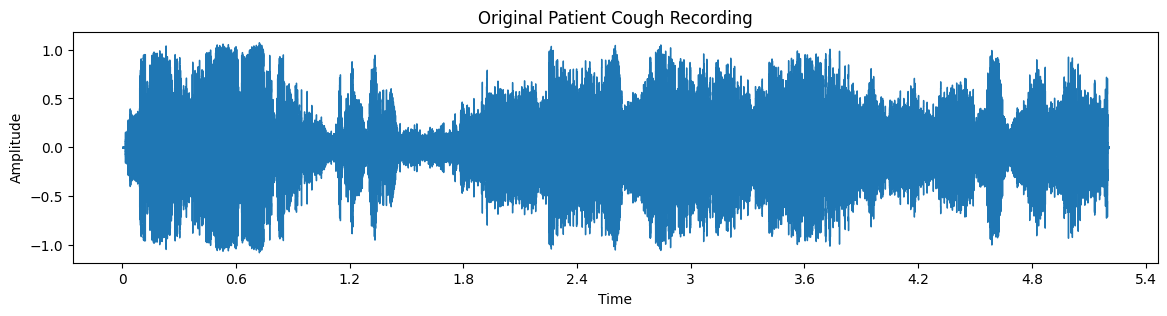

In [7]:
plt.figure(figsize=(14,3))
librosa.display.waveshow(audio, sr=sr)
plt.title("Original Patient Cough Recording")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

### Code Explanation

- `plt.figure(figsize=(14, 3))` creates a figure with a width of 14 inches and a height of 3 inches.
- `librosa.display.waveshow(audio, sr=sr)` plots the waveform of the audio signal.
- `sr=sr` ensures the time axis is displayed correctly based on the sampling rate.
- `plt.title()` adds a title to the plot.
- `plt.xlabel()` and `plt.ylabel()` label the X-axis (Time) and Y-axis (Amplitude).
- `plt.show()` displays the waveform.

# Step 7: Reduce Background Noise

Real-world audio recordings often contain unwanted background sounds such as fan noise, traffic, wind, or other environmental disturbances. These noises can affect the quality of the audio and reduce the accuracy of machine learning models.

Noise reduction helps suppress unwanted sounds while preserving the important information in the audio signal, resulting in cleaner audio for further processing.

In [8]:
clean_audio = nr.reduce_noise(
    y=audio,
    sr=sr
)

### Code Explanation

- `nr.reduce_noise()` applies noise reduction to the input audio signal.
- `y=audio` specifies the original audio signal.
- `sr=sr` provides the sampling rate, which helps the algorithm process the audio correctly.
- The cleaned audio is stored in the variable `clean_audio` for use in the subsequent preprocessing steps.

### Listen to the Noise-Reduced Audio

Play the processed audio to hear the effect of noise reduction. Compare it with the original recording and observe whether the background noise has been reduced while preserving the important audio content.

In [9]:
Audio(clean_audio,rate=sr)

### Code Explanation

- `Audio(clean_audio, rate=sr)` creates an audio player for the denoised audio.
- `clean_audio` is the audio signal after noise reduction.
- `rate=sr` plays the audio at the original sampling rate.

### Visualize the Noise-Reduced Waveform

The waveform of the denoised audio helps us observe the signal after background noise has been reduced. Comparing it with the original waveform provides a visual understanding of the preprocessing step.

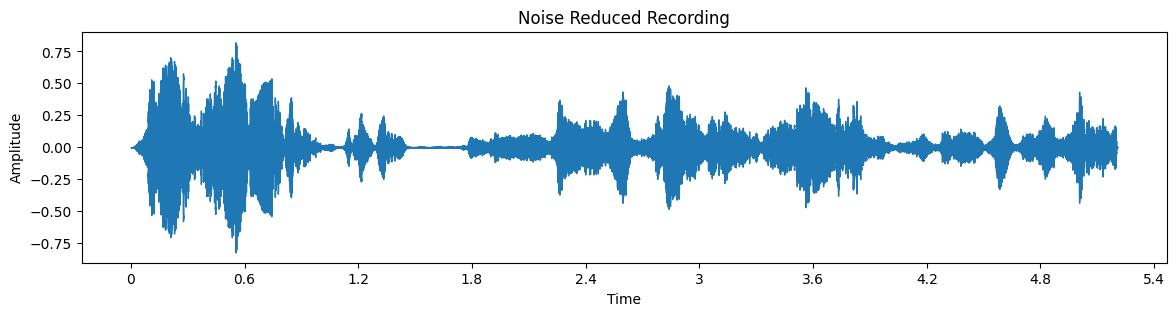

In [10]:
plt.figure(figsize=(14,3))
librosa.display.waveshow(clean_audio, sr=sr)
plt.title("Noise Reduced Recording")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

### Code Explanation

- `waveshow(clean_audio, sr=sr)` plots the denoised audio waveform.
- The X-axis represents time, and the Y-axis represents amplitude.
- The plot helps visualize the cleaned audio signal.

### Save the Noise-Reduced Audio

The cleaned audio is saved as a new WAV file. This file can be used for further preprocessing, feature extraction, or model training.

In [11]:
sf.write("noise_reduced.wav",clean_audio,sr)

### Code Explanation

- `sf.write()` saves the processed audio to a file.
- `"noise_reduced.wav"` is the output filename.
- `clean_audio` is the denoised audio signal.
- `sr` preserves the original sampling rate.

# Step 8: Normalize the Audio

Different audio recordings may have different loudness levels. Audio normalization scales the amplitude of the signal to a standard range without changing its content.

This makes recordings more consistent and improves the reliability of feature extraction and machine learning models.

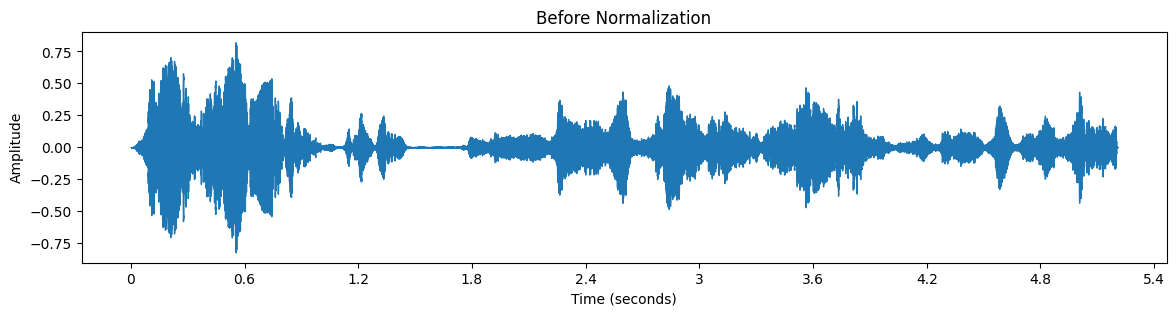

In [12]:
plt.figure(figsize=(14,3))
librosa.display.waveshow(clean_audio, sr=sr)
plt.title("Before Normalization")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

In [13]:
normalized_audio=librosa.util.normalize(clean_audio)

### Code Explanation

- `librosa.util.normalize()` scales the audio signal to the maximum allowable amplitude.
- The waveform shape remains unchanged.
- The normalized audio is stored in `normalized_audio`.

### Listen to the Normalized Audio

Play the normalized audio and compare it with the previous recording. You may notice a more consistent loudness while the actual sound content remains unchanged.

In [14]:
Audio(normalized_audio,rate=sr)

### Code Explanation

- `Audio(normalized_audio, rate=sr)` creates an audio player for the normalized signal.
- The playback uses the original sampling rate.

### Visualize the Normalized Waveform

This waveform shows the audio after normalization. Notice that the overall shape remains the same, while the amplitude has been scaled to a standard range.

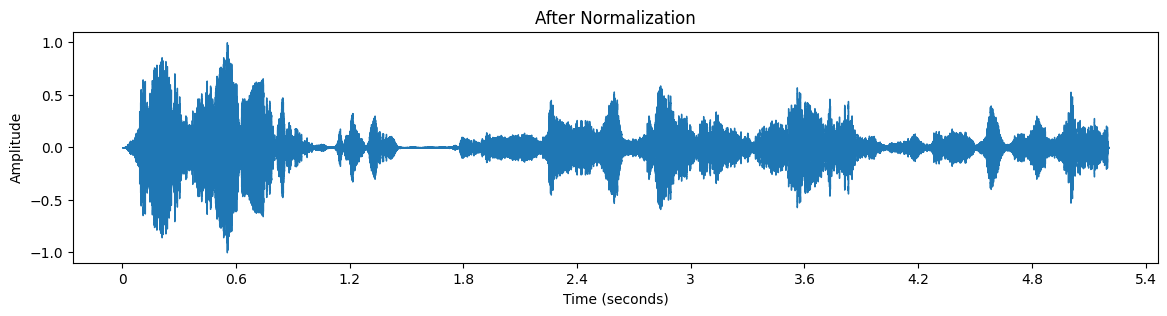

In [15]:
plt.figure(figsize=(14,3))
librosa.display.waveshow(normalized_audio, sr=sr)
plt.title("After Normalization")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

### Code Explanation

- `waveshow(normalized_audio, sr=sr)` displays the normalized waveform.
- The plot helps visualize the effect of amplitude scaling.

### Compare Before and After Normalization

Displaying the waveforms together makes it easier to observe the effect of normalization. Although the amplitude changes, the audio content and timing remain unchanged.

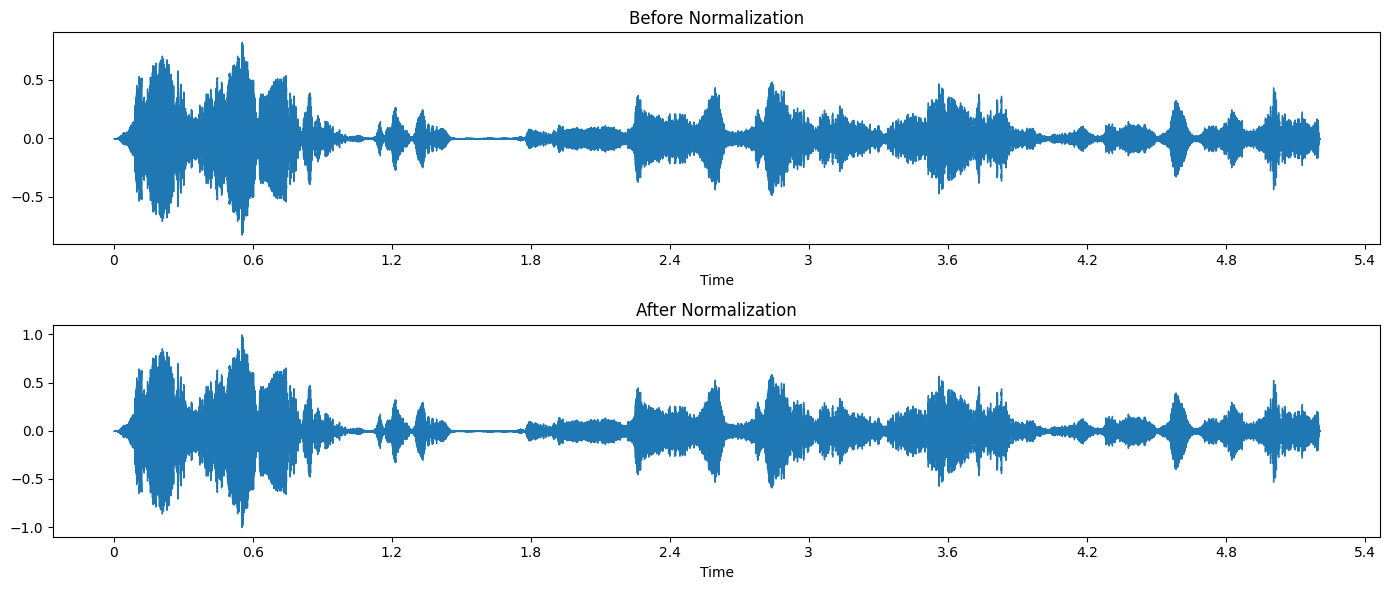

In [16]:
plt.figure(figsize=(14,6))

plt.subplot(2,1,1)
librosa.display.waveshow(clean_audio, sr=sr)
plt.title("Before Normalization")

plt.subplot(2,1,2)
librosa.display.waveshow(normalized_audio, sr=sr)
plt.title("After Normalization")

plt.tight_layout()
plt.show()

### Code Explanation

- `plt.subplot()` creates two plots in a single figure.
- The first subplot displays the waveform before normalization.
- The second subplot displays the waveform after normalization.
- `plt.tight_layout()` adjusts the spacing between the plots.

Before Normalization: The maximum amplitude reaches only about ±0.7, so the recording is relatively softer.

After Normalization: The waveform has been scaled to use the full amplitude range (approximately ±1). The shape of the cough remains exactly the same—only the loudness has been standardized.

✅ The cough pattern did not change.

✅ The timing did not change.

✅ The frequency content did not change.

✅ Only the amplitude (loudness) was scaled.

In [17]:
sf.write("normalized_audio.wav",normalized_audio,sr)

## Normalized Audio Waveform

The normalized waveform represents the final preprocessed audio signal. This audio is now cleaner, has a consistent loudness, and is ready for feature extraction.

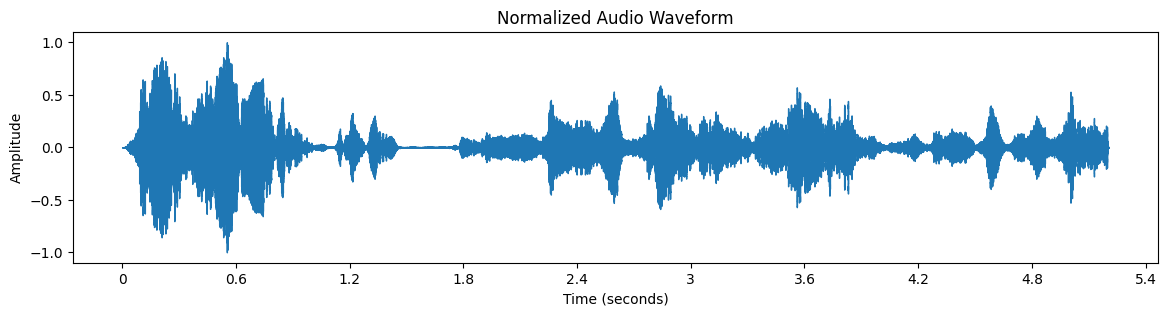

In [19]:
plt.figure(figsize=(14,3))
librosa.display.waveshow(normalized_audio, sr=sr)
plt.title("Normalized Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

### Code Explanation

- `waveshow(normalized_audio, sr=sr)` plots the normalized waveform.
- The X-axis represents time, while the Y-axis represents amplitude.
- This visualization confirms the final audio that will be used for feature extraction.

# Step 9: Generate a Spectrogram

A spectrogram is a visual representation of how the frequency content of an audio signal changes over time.

Unlike a waveform, which shows amplitude over time, a spectrogram reveals both the time and frequency information, making it useful for speech and sound analysis.

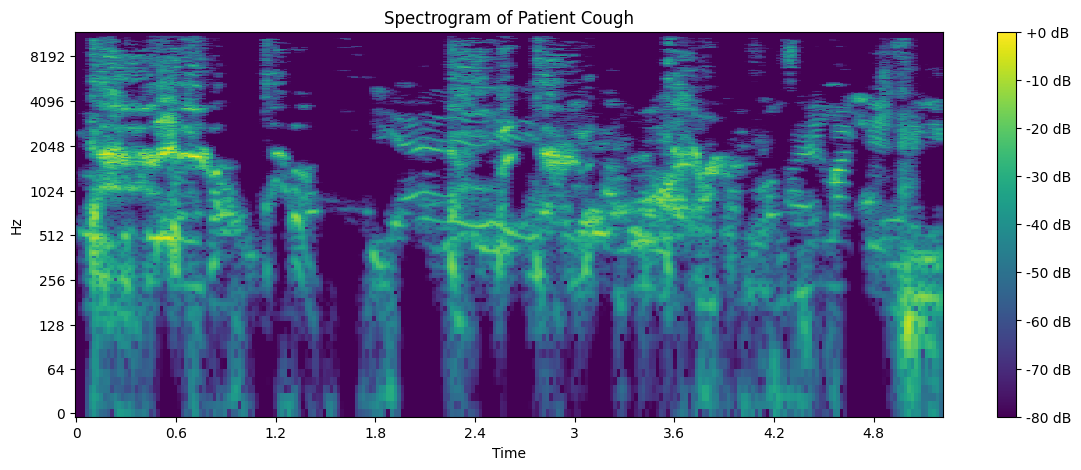

In [20]:
D = np.abs(librosa.stft(normalized_audio))

plt.figure(figsize=(14,5))
librosa.display.specshow(
    librosa.amplitude_to_db(D, ref=np.max),
    sr=sr,
    x_axis='time',
    y_axis='log',
    cmap='viridis'
)

plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram of Patient Cough")
plt.show()

### Code Explanation

- `librosa.stft()` computes the Short-Time Fourier Transform (STFT).
- `np.abs()` extracts the magnitude of the frequency components.
- `amplitude_to_db()` converts amplitudes to the decibel (dB) scale.
- `specshow()` visualizes the spectrogram.
- The color intensity represents the energy of different frequencies.

# Step 10: Extract MFCC Features

Mel-Frequency Cepstral Coefficients (MFCCs) are one of the most widely used audio features in speech recognition and audio classification.

Instead of using the raw audio signal, machine learning models often use MFCCs because they provide a compact representation of the important characteristics of sound.

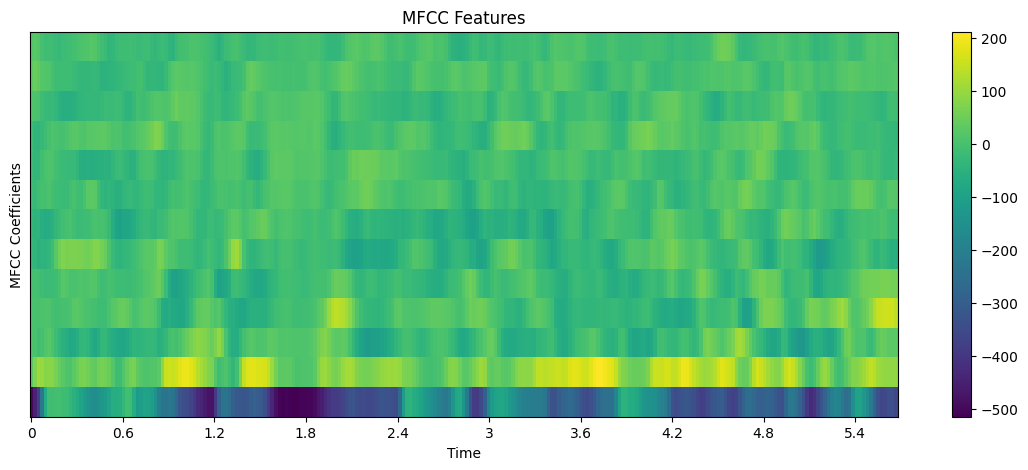

In [21]:
mfcc = librosa.feature.mfcc(
    y=normalized_audio,
    sr=sr,
    n_mfcc=13
)

plt.figure(figsize=(14,5))
librosa.display.specshow(
    mfcc,
    x_axis='time',
    cmap='viridis'
)

plt.colorbar()
plt.title("MFCC Features")
plt.ylabel("MFCC Coefficients")
plt.show()

### Code Explanation

- `librosa.feature.mfcc()` extracts MFCC features from the normalized audio.
- `n_mfcc=13` specifies that 13 MFCC coefficients should be computed.
- `specshow()` visualizes the extracted MFCC features.
- The resulting matrix can be used as input for machine learning models.

In [22]:
print("MFCC Shape: ", mfcc.shape)

MFCC Shape:  (13, 245)


### Understanding the MFCC Output

The shape of the MFCC matrix indicates the number of coefficients extracted for each time frame.

For example:

- Rows → MFCC coefficients
- Columns → Time frames

This numerical representation is much more suitable for machine learning than raw audio samples.

# Step 11: Install CLAP Dependencies

To generate audio embeddings using the CLAP model, we install the required libraries, including Hugging Face Transformers and PyTorch.

In [23]:
!pip -q install transformers librosa torch

In [24]:
import torch
from transformers import ClapProcessor,ClapModel

## Load the Pre-trained CLAP Model

CLAP (Contrastive Language-Audio Pretraining) is a foundation model that converts audio into high-dimensional numerical embeddings.

These embeddings capture rich semantic information from the audio and can be used for tasks such as classification, retrieval, and similarity search.



In [25]:
processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")
model = ClapModel.from_pretrained("laion/clap-htsat-unfused")


preprocessor_config.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/5.39k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/615M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/614M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/447 [00:00<?, ?it/s]

### Code Explanation

- `ClapProcessor` prepares the audio for the model.
- `ClapModel` loads the pre-trained CLAP model.
- `from_pretrained()` downloads the model weights from Hugging Face.

## Resample the Audio

The CLAP model expects audio sampled at **48 kHz**. Therefore, the normalized audio is resampled from its original sampling rate to **48,000 Hz** before generating embeddings.

In [28]:
normalized_audio_48k = librosa.resample(normalized_audio, orig_sr=sr, target_sr = 48000)
sr_48k = 48000

### Code Explanation

- `librosa.resample()` converts the audio to 48 kHz.
- `orig_sr` specifies the original sampling rate.
- `target_sr=48000` sets the required sampling rate for the CLAP model.

## Prepare the Audio Input

The processor converts the resampled audio into tensors that the CLAP model can understand.

In [29]:
inputs = processor(
    audio = normalized_audio_48k,
    sampling_rate = sr_48k,
    return_tensors = "pt"
)


### Code Explanation

- `processor()` preprocesses the audio.
- `return_tensors="pt"` returns the processed data as PyTorch tensors.
- These tensors are passed to the CLAP model.

## Generate Audio Embeddings

The CLAP model processes the input audio and generates a numerical embedding that captures its important characteristics.

In [30]:
with torch.no_grad():
  audio_embeddings = model.get_audio_features(**inputs)

### Code Explanation

- `torch.no_grad()` disables gradient computation during inference.
- `model.get_audio_features()` generates the audio embedding.
- The output contains a high-level representation of the audio.

## Inspect the Embedding

The generated embedding is a numerical vector representing the audio.

The output shape indicates:

- Number of audio samples processed
- Length of the embedding vector

In [32]:
print(type(audio_embeddings))

<class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>


In [33]:
print(audio_embeddings.pooler_output.shape)

torch.Size([1, 512])


### Sample Embedding Values

The embedding consists of floating-point numbers learned by the CLAP model. These values represent meaningful audio characteristics and are used internally by machine learning models for downstream tasks.



In [34]:
audio_embeddings.pooler_output[0][:20]

tensor([ 0.0185, -0.0600,  0.0722,  0.0658,  0.0287,  0.0377,  0.0514, -0.0131,
         0.0186, -0.0411, -0.0422, -0.1255, -0.0228,  0.0321, -0.0756,  0.0510,
        -0.0319, -0.0803, -0.0410, -0.0372])

In [35]:
audio_embeddings.pooler_output

tensor([[ 1.8482e-02, -6.0026e-02,  7.2231e-02,  6.5807e-02,  2.8749e-02,
          3.7681e-02,  5.1370e-02, -1.3125e-02,  1.8609e-02, -4.1108e-02,
         -4.2192e-02, -1.2555e-01, -2.2798e-02,  3.2148e-02, -7.5573e-02,
          5.1010e-02, -3.1874e-02, -8.0261e-02, -4.0969e-02, -3.7171e-02,
         -2.9895e-02, -3.1728e-03,  3.8612e-02, -2.1310e-02, -4.3838e-02,
          3.7449e-02, -6.2536e-03,  5.4782e-02,  3.7725e-02, -1.3720e-02,
          1.7933e-02,  4.3733e-02, -6.7424e-02, -1.6763e-02,  3.4369e-02,
          9.1948e-02, -2.9541e-02, -2.7665e-02, -7.1944e-02, -3.3608e-02,
         -1.0638e-02,  2.3744e-02,  5.8367e-02, -2.2358e-02, -5.3334e-02,
         -4.4942e-02,  2.1681e-02, -5.0059e-02, -5.5726e-02, -3.0102e-02,
         -8.9060e-03,  2.2878e-02, -4.6713e-02, -1.0020e-04,  7.3318e-02,
         -2.4170e-02,  4.7369e-02, -4.1840e-03, -6.4434e-02,  9.8678e-02,
         -6.4723e-02, -7.0650e-02,  9.9832e-02,  1.7453e-02,  2.9103e-02,
          5.8047e-02, -1.9636e-02, -5.

In [37]:
print("=" * 60)
print("🎉 Audio Preprocessing Pipeline Completed Successfully!")
print("The audio has been cleaned, normalized, and converted into AI-ready features.")
print("=" * 60)

🎉 Audio Preprocessing Pipeline Completed Successfully!
The audio has been cleaned, normalized, and converted into AI-ready features.


In [36]:
embedding = audio_embeddings.pooler_output
print("Embedding shape: ", embedding.shape)
print("Embedding Dimension: ", embedding.shape[1])

Embedding shape:  torch.Size([1, 512])
Embedding Dimension:  512


## Final Output

The final embedding has **512 dimensions**, meaning each audio recording is represented by a vector of 512 numerical features.

This compact representation can be used as input for tasks such as:

- Audio classification
- Sound similarity search
- Audio retrieval
- Foundation model applications
- Deep learning pipelines

# Summary

In this notebook, we built a complete audio preprocessing pipeline for AI and Machine Learning applications.

The preprocessing steps performed were:

- ✅ Uploaded an audio file
- ✅ Loaded the audio into Python
- ✅ Visualized the original waveform
- ✅ Reduced background noise
- ✅ Normalized the audio
- ✅ Generated waveform and spectrogram visualizations
- ✅ Extracted MFCC features
- ✅ Generated CLAP audio embeddings

The final output is an AI-ready numerical representation of the audio that can be used for tasks such as audio classification, speech analysis, sound event detection, and deep learning applications.

# Next Steps

After preprocessing and feature extraction, the generated features can be used to build machine learning or deep learning models.

Some common applications include:

- 🎙 Speech Recognition
- 🫁 Cough Detection
- 🩺 Disease Diagnosis
- 😊 Emotion Recognition
- 🔊 Speaker Identification
- 🎵 Music Classification
- 🔍 Audio Similarity Search

> **Key Takeaway**

Raw audio is rarely used directly for machine learning. Instead, it is first cleaned, standardized, and transformed into meaningful numerical features that AI models can effectively learn from.